Author: Turbat Turkhuu

Date: March 2026

- Disclaimer: All data used in this report are publicly available and there are no data restrictions involved

# Introduction

The Australian Renewable Energy Agency (ARENA) aims to support the transition to renewable energy through evidence-based policy and targeted investment strategies. A big challenge in achieving widespread solar adoption is the significant variation in uptake across different areas.

This project investigates whether Melbourne suburbs can be grouped into distinct clusters based on solar adoption behaviour, housing characteristics, and socioeconomic indicators. Identifying such clusters can help inform more targeted renewable energy incentives and policy interventions.

# Data Sources
Melbourne Housing Dataset (2016-2017) - Source: Ms. Yuthika

Solar Installation Dataset (2011–2023) - Source: Ms. Yuthika

Solar Capacity Dataset (2011–2023) - Source: Ms. Yuthika

Australian Taxation Data (2012–2023) - Source: https://data.gov.au/data/dataset/taxation-statistics-postcode-data/resource/00a01ddb-69ee-4f3c-bd74-e1a7840f4610

# Data Cleaning and Preparation

Severalsteps were done to prepare the datasets for analysis.

Non-Victorian postcodes were filtered using postcode ranges (3000–3999 and 8000–8999). Missing values were handled by removing invalid entries and converting numeric fields where necessary.

Solar installation and capacity datasets were added across years (2011–2023) to produce total installations and total capacity per postcode.

The housing dataset was cleaned by converting price values to numeric format and computing the median house price per postcode.

Tax datasets were processed to extract postcode-level income and population data, which were later used to compute income per person.

Finally, all datasets were merged using postcode as the common key, creating a comprehensive dataset.

# Feature Extraction

To ensure meaningful clustering, several derived features were created.

Median house price: represents property value levels per postcode.

Total solar installations: overall adoption volume

Installations per property: calculated using installation per postcode and property count per postcode

Total solar capacity: total energy generation capacity

Capacity per installation: average system size per installation

# Normalization

Because the features are measured on different scales (e.g., income vs installation rates), StandardScaler was applied to ensure each variable contributed equally to the clustering process.

# Clustering

Kmeans clustering was used for this report but the other notable clustering technique is Hierarchical Clustering.

K-Means clustering was selected as the primary algorithm due to its efficiency and interpretability for large datasets. The algorithm partitions observations into clusters by minimising within-cluster variance using distance.

Hierarchical clustering was considered as an alternative method. Unlike K-Means, it does not require pre-specifying the number of clusters and provides a dendrogram for visualising relationships. However, it is computationally more expensive and less scalable for larger datasets.

#### Import necessary libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [2]:
solar_capacity = pd.read_csv("solar/sgu-solar-capacity-2011-to-present.csv")
solar_installation = pd.read_csv("solar/sgu-solar-installations-2011-to-present.csv")
tax_2012 = pd.read_csv(
    "tax-records/tax-2012-postcode.csv",
    header=2,
    low_memory=False
)
tax_2023 = pd.read_csv(
    "tax-records/tax-2023-postcode.csv",
    header=1,
    low_memory=False
)

tax_2012 = tax_2012.drop_duplicates()
tax_2012 = tax_2012.fillna(0)

solar_installation["Small Unit Installation Postcode"] = pd.to_numeric(
    solar_installation["Small Unit Installation Postcode"],
    errors="coerce"
)

vic_solar_installation = solar_installation[
    (
        (solar_installation["Small Unit Installation Postcode"] >= 3000) &
        (solar_installation["Small Unit Installation Postcode"] <= 3999)
    ) |
    (
        (solar_installation["Small Unit Installation Postcode"] >= 8000) &
        (solar_installation["Small Unit Installation Postcode"] <= 8999)
    )
]

vic_solar_installation.to_csv("victoria_installations.csv", index=False)

solar_capacity["Small Unit Installation Postcode"] = pd.to_numeric(
    solar_capacity["Small Unit Installation Postcode"],
    errors="coerce"
)

vic_solar_capacity = solar_capacity[
    (
        (solar_capacity["Small Unit Installation Postcode"] >= 3000) &
        (solar_capacity["Small Unit Installation Postcode"] <= 3999)
    ) |
    (
        (solar_capacity["Small Unit Installation Postcode"] >= 8000) &
        (solar_capacity["Small Unit Installation Postcode"] <= 8999)
    )
]

vic_solar_capacity.to_csv("victoria_capacity.csv", index=False)


tax_2012["Postcode"] = pd.to_numeric(
    tax_2012["Postcode"],
    errors="coerce"
)

tax_small = tax_2012[
    [
        "Postcode",
        "Number of individuals\nno.",
        "Taxable income or loss\n$"
    ]
].copy()

vic_tax_2012 = tax_small[
    (
        (tax_small["Postcode"] >= 3000) &
        (tax_small["Postcode"] <= 3999)
    ) |
    (
        (tax_small["Postcode"] >= 8000) &
        (tax_small["Postcode"] <= 8999)
    )
]

vic_tax_2012.to_csv("2012_victoria_tax.csv", index=False)

tax_2023["Postcode"] = pd.to_numeric(
    tax_2023["Postcode"],
    errors="coerce"
)

tax_small = tax_2023[
    [
        "Postcode",
        "Individuals\nno.",
        "Taxable income or loss4\n$"
    ]
].copy()

vic_tax_2023 = tax_small[
    (
        (tax_small["Postcode"] >= 3000) &
        (tax_small["Postcode"] <= 3999)
    ) |
    (
        (tax_small["Postcode"] >= 8000) &
        (tax_small["Postcode"] <= 8999)
    )
]

vic_tax_2023.to_csv("2023_victoria_tax.csv", index=False)

In [14]:
solar_capacity = pd.read_csv("solar/victoria_capacity.csv")
solar_installation = pd.read_csv("solar/victoria_installations.csv")
melbourne_houses = pd.read_csv("houses/Melbourne_housing_FULL.csv")
tax_2016 = pd.read_csv(
    "tax-records/tax-2016-postcode.csv",
    header=2,
    low_memory=False
)

# Total solar installation 
year_cols_install = [
    col for col in solar_installation.columns
    if any(str(year) in col for year in range(2011, 2024))
]
total_solar_installation = solar_installation[['Small Unit Installation Postcode']].copy()
total_solar_installation['total_installation'] = solar_installation[year_cols_install].sum(axis=1)
total_solar_installation = total_solar_installation.rename(
    columns={'Small Unit Installation Postcode': 'Postcode'}
)

#Total Solar capacity
year_cols_capacity = [
    col for col in solar_capacity.columns
    if any(str(year) in col for year in range(2011, 2024))
]
total_solar_capacity = solar_capacity[['Small Unit Installation Postcode']].copy()
total_solar_capacity['total_capacity'] = solar_capacity[year_cols_capacity].sum(axis=1)
total_solar_capacity = total_solar_capacity.rename(
    columns={'Small Unit Installation Postcode': 'Postcode'}
)

#Average melbourne home price and property count
melbourne_houses['Price'] = pd.to_numeric(melbourne_houses['Price'], errors='coerce')
avg_melbourne_houses = (
    melbourne_houses
        .assign(Price=pd.to_numeric(melbourne_houses['Price'], errors='coerce'))
        .groupby('Postcode')
        .agg(
            Propertycount=('Propertycount', 'first'),
            MedianPrice=('Price', 'median')
        )
        .reset_index()
)

tax_2016["Postcode"] = pd.to_numeric(
    tax_2016["Postcode"],
    errors="coerce"
)

tax_small = tax_2016[
    [
        "Postcode",
        "Number of individuals\nno.",
        "Taxable income or loss3 \n$"
    ]
].copy()

vic_tax_2016 = tax_small[
    (
        (tax_small["Postcode"] >= 3000) &
        (tax_small["Postcode"] <= 3999)
    ) |
    (
        (tax_small["Postcode"] >= 8000) &
        (tax_small["Postcode"] <= 8999)
    )
]

vic_tax_2016.to_csv("2016_victoria_tax.csv", index=False)

main = (
    total_solar_installation
    .merge(total_solar_capacity, on='Postcode')
    .merge(avg_melbourne_houses, on='Postcode')
    .merge(vic_tax_2016, on='Postcode')
)

# Finding average capacity per installation
main["capacity_per_installation"] = (
    main["total_capacity"]
    / main["total_installation"]
)

main = main.rename(
    columns={
        'Number of individuals\nno.': 'Individuals',
        'Taxable income or loss3 \n$': 'Taxable income or loss'
    }
)

#Changing the dataype to become float instead of string
main["Individuals"] = (
    main["Individuals"]
    .astype(str)
    .str.replace(",", "")
    .astype(float)
)

main["Taxable income or loss"] = (
    main["Taxable income or loss"]
    .astype(str)
    .str.replace(",", "")
    .astype(float)
)

# Average income per person
main["income_per_person"] = (
    main["Taxable income or loss"]
    / main["Individuals"]
)

# Finding the average installation per property
main["installation_per_propety"] = (
    main["total_installation"]
    / main["Propertycount"]
)

main.to_csv("2016_comp_solar.csv", index=False)

features =[
    "installation_per_propety",
    "capacity_per_installation",
    "income_per_person",
    "MedianPrice"
]
# Handle missing values using the median of the other rows
imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(main[features])

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Optimal Number of Clusters

The elbow method was used to evaluate the optimal number of clusters. The elbow shape was moderately pronounced and silhouette score was used in addition to ensure cluster quality. Based on the combination of silhouette analysis and interpretability, K = 5 was selected as the optimal number of clusters.

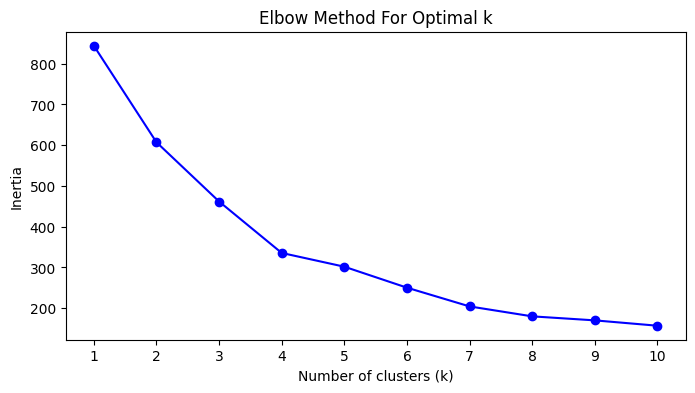

In [15]:
from sklearn.cluster import KMeans

k_values = range(1, 11)
inertia = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_values, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.xticks(k_values)
plt.show()

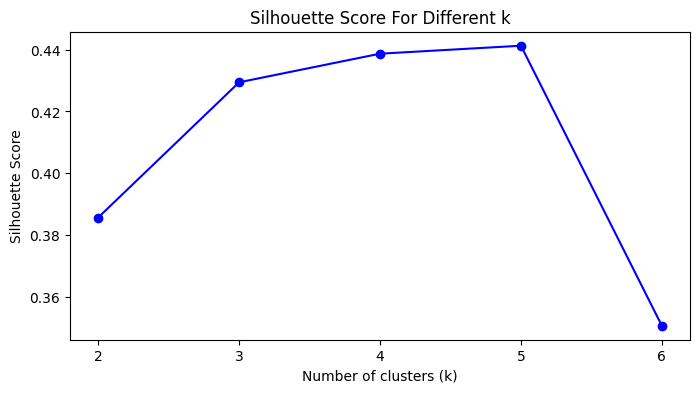

In [16]:
from sklearn.metrics import silhouette_score

k_values = range(2, 7)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

plt.figure(figsize=(8, 4))
plt.plot(k_values, silhouette_scores, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score For Different k')
plt.xticks(k_values)
plt.show()

# Clustering Results

The final model assigned each postcode to one of five clusters. Principal Component Analysis (PCA) was used to reduce the dataset to two dimensions for visualisation purposes. Cluster distribution is uneven, which reflected natural variation in Melbourne suburbs.

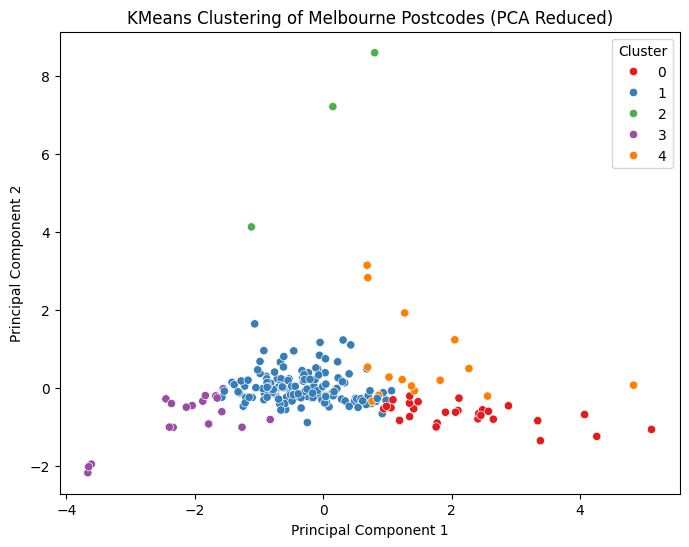

         installation_per_propety  capacity_per_installation  \
cluster                                                        
0                        0.265960                   6.333675   
1                        0.356038                   6.375254   
2                        0.158489                  27.292306   
3                        1.930793                   6.128494   
4                        0.077545                   9.112709   

         income_per_person   MedianPrice  
cluster                                   
0             87886.360200  1.544234e+06  
1             55308.606378  8.162202e+05  
2             54659.019937  5.775000e+05  
3             47999.821571  6.069861e+05  
4             94835.572928  9.691333e+05  


In [22]:
from sklearn.decomposition import PCA

kmeans = KMeans(n_clusters=5,random_state=42)

kmeans.fit(X_scaled)
main['cluster'] = kmeans.labels_

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

main['pc1'] = principal_components[:, 0]
main['pc2'] = principal_components[:, 1]

# Plot the clusters
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='pc1',
    y='pc2',
    hue='cluster',
    palette='Set1',
    data=main
)

plt.title('KMeans Clustering of Melbourne Postcodes (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

# Cluster Interpetation 

Cluster 0 – Wealthy Moderate Adoption Suburbs

This cluster is characterised by high median house prices and relatively high income levels. Solar adoption is moderate, suggesting that wealth alone does not guarantee high uptake.

Cluster 1 – Mid-Income Steady Adoption Suburbs

This group represents suburbs with moderate income and moderate solar adoption rates. These areas reflect typical suburban behaviour and steady uptake of solar technology.

Cluster 2 – Low Adoption, High Capacity Installations

This cluster exhibits low installation rates but unusually high capacity per installation. This may indicate atypical installation patterns or large commercial areas.

Cluster 3 – High Solar Adoption Suburbs

This cluster has extremely high installations per property, indicating strong solar adoption behaviour. These suburbs represent renewable energy hotspots.

Cluster 4 – High-Income Low Adoption Suburbs

This cluster consists of high-income, high-property-value suburbs with very low solar adoption rates. This may reflect barriers such as luxury apartments in the CBD with minimal roof space.

In [23]:
cluster_summary = (
    main
    .groupby("cluster")[features]
    .mean()
)
print(cluster_summary)

         installation_per_propety  capacity_per_installation  \
cluster                                                        
0                        0.265960                   6.333675   
1                        0.356038                   6.375254   
2                        0.158489                  27.292306   
3                        1.930793                   6.128494   
4                        0.077545                   9.112709   

         income_per_person   MedianPrice  
cluster                                   
0             87886.360200  1.544234e+06  
1             55308.606378  8.162202e+05  
2             54659.019937  5.775000e+05  
3             47999.821571  6.069861e+05  
4             94835.572928  9.691333e+05  


# Significance Testing

To validate the statistical significance of the clustering results, ANOVA tests were conducted across clusters for key variables such as income per person, house price, and solar adoption metrics.

The results indicate statistically significant differences between clusters (p < 0.05), confirming that the identified clusters are meaningfully distinct rather than random groupings.

In [33]:
from scipy.stats import f_oneway

features = [
    "income_per_person",
    "MedianPrice",
    "installation_per_propety",
    "capacity_per_installation"
]

for feature in features:
    groups = [
        main[main["cluster"] == c][feature].dropna()
        for c in main["cluster"].unique()
    ]
    
    f_stat, p_value = f_oneway(*groups)
    
    print(f"\nFeature: {feature}")
    print(f"F-statistic: {f_stat:.4f}")
    print(f"p-value: {p_value:.6f}")
    
    if p_value < 0.05:
        print("Result: Statistically significant differences between clusters (p < 0.05)")
    else:
        print("Result: No statistically significant difference between clusters")


Feature: income_per_person
F-statistic: 72.4169
p-value: 0.000000
Result: Statistically significant differences between clusters (p < 0.05)

Feature: MedianPrice
F-statistic: 84.0269
p-value: 0.000000
Result: Statistically significant differences between clusters (p < 0.05)

Feature: installation_per_propety
F-statistic: 85.3650
p-value: 0.000000
Result: Statistically significant differences between clusters (p < 0.05)

Feature: capacity_per_installation
F-statistic: 145.3055
p-value: 0.000000
Result: Statistically significant differences between clusters (p < 0.05)


# Key Findings

- Melbourne suburbs exhibit distinct solar adoption patterns rather than uniform behaviour
- Income and house price are not direct predictors of solar adoption
- A clear group of high solar adoption suburbs exists
- High-income suburbs often exhibit low solar adoption, indicating structural barriers
- Some suburbs show atypical high-capacity installations, suggesting heterogeneous solar system behaviour

# Recommendations

Based on the clustering results, several policy insights emerge:

1. Target high-income low-adoption suburbs
    - These areas may face non-financial barriers such as apartment living or regulatory constraints. Policy interventions should focus on shared solar schemes or building-level incentives.
2. Support mid-income suburbs with stable adoption
    - These suburbs demonstrate consistent uptake and may benefit from continued rebate schemes to sustain adoption momentum.
3. Investigate high-capacity installation suburbs
    - Further analysis is recommended to determine whether these represent commercial installations or data aggregation anomalies.
4. Encourage expansion in low-adoption regions
    - Tailored outreach programs may be required in suburbs with consistently low solar uptake.

# Conclusion

This analysis demonstrates that Melbourne suburbs can be meaningfully grouped into distinct clusters based on solar adoption behaviour, housing characteristics, and socioeconomic indicators. The results highlight significant variation in renewable energy uptake and provide evidence to support targeted policy interventions aimed at improving solar adoption across different suburb types.

# References

Significance Testing: https://www.geeksforgeeks.org/maths/tests-of-significance/#significance-testing

Datasets: Ms. Yuthika and ABS